## Feature Engieering
### Objective:

Using data from ~3,900 customers, this notebook:
1. Derives metrics for value, loyalty, and promo dependency
2. Creates a final dataset for SQL querying and Power BI reporting



---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ---- CONFIGURING PATH ----
RAW_PATH = r'..\data\raw\Dataset.csv'
OUT_PATH = r'..\data\engineered\customer_features_enriched.csv'

# Plotting style
plt.rcParams.update({
    'figure.facecolor': '#121212',
    'axes.facecolor':   '#1f2937',
    'axes.edgecolor':   '#4b5563',
    'text.color':       '#f3f4f6',
    'xtick.color':      '#d1d5db',
    'ytick.color':      '#d1d5db',
    'grid.color':       '#374151',
    'axes.titlecolor':  '#ffffff',
    'axes.labelcolor':  '#e5e7eb',
    'font.family':      'monospace',
    'figure.dpi':       120,
})
ACCENT_COLORS = ['#3b82f6', '#10b981', '#f59e0b', '#ef4444', '#8b5cf6']

print('Libraries loaded successfully.')

Libraries loaded successfully.


---

In [2]:
# 1. Load Raw Data

df = pd.read_csv(RAW_PATH)
print(f'Rows: {df.shape[0]:,} | Columns: {df.shape[1]}')
df.head(5)

Rows: 3,900 | Columns: 18


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [3]:
print('COLUMN TYPES')
print(df.dtypes)
print()
print('NULL COUNTS')
print(df.isnull().sum())
print()
print('NUMERIC STATS')
df.describe()

COLUMN TYPES
Customer ID                 int64
Age                         int64
Gender                     object
Item Purchased             object
Category                   object
Purchase Amount (USD)       int64
Location                   object
Size                       object
Color                      object
Season                     object
Review Rating             float64
Subscription Status        object
Shipping Type              object
Discount Applied           object
Promo Code Used            object
Previous Purchases          int64
Payment Method             object
Frequency of Purchases     object
dtype: object

NULL COUNTS
Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0


,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3863.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750065,25.351538
std,1125.977353,15.207589,23.685392,0.716983,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [4]:

cat_cols = ['Gender','Category','Season','Subscription Status','Shipping Type',
            'Discount Applied','Promo Code Used','Frequency of Purchases','Payment Method']
for col in cat_cols:
    print(f'--- {col} ---')
    print(df[col].value_counts())
    print()

--- Gender ---
Gender
Male      2652
Female    1248
Name: count, dtype: int64

--- Category ---
Category
Clothing       1737
Accessories    1240
Footwear        599
Outerwear       324
Name: count, dtype: int64

--- Season ---
Season
Spring    999
Fall      975
Winter    971
Summer    955
Name: count, dtype: int64

--- Subscription Status ---
Subscription Status
No     2847
Yes    1053
Name: count, dtype: int64

--- Shipping Type ---
Shipping Type
Free Shipping     675
Standard          654
Store Pickup      650
Next Day Air      648
Express           646
2-Day Shipping    627
Name: count, dtype: int64

--- Discount Applied ---
Discount Applied
No     2223
Yes    1677
Name: count, dtype: int64

--- Promo Code Used ---
Promo Code Used
No     2223
Yes    1677
Name: count, dtype: int64

--- Frequency of Purchases ---
Frequency of Purchases
Every 3 Months    584
Annually          572
Quarterly         563
Monthly           553
Bi-Weekly         547
Fortnightly       542
Weekly            5

**Observation:** `Discount Applied` and `Promo Code` Used are fully correlated, meaning customers who used one also used the other. Therefore, they will be treated as a single feature.

---
## 2. Data Cleaning

In [5]:
df_clean = df.copy()

# --- Standardise text columns ---
str_cols = df_clean.select_dtypes(include='object').columns
for col in str_cols:
    df_clean[col] = df_clean[col].str.strip().str.title()

# Use median imputation: safe, non-distorting for a skewed rating distribution
rating_median = df_clean['Review Rating'].median()
df_clean['Review Rating'] = df_clean['Review Rating'].fillna(rating_median)
print(f'Review Rating nulls after imputation: {df_clean["Review Rating"].isnull().sum()}')

# --- Remove duplicates ---
before = len(df_clean)
df_clean.drop_duplicates(inplace=True)
print(f'Dropped {before - len(df_clean)} duplicate rows.')

df_clean.columns = [
    col.strip()
       .lower()
       .replace(' ', '_')
       .replace('(', '')
       .replace(')', '')
    for col in df_clean.columns
]
print(f'Cleaned columns: {list(df_clean.columns)}')

Review Rating nulls after imputation: 0
Dropped 0 duplicate rows.
Cleaned columns: ['customer_id', 'age', 'gender', 'item_purchased', 'category', 'purchase_amount_usd', 'location', 'size', 'color', 'season', 'review_rating', 'subscription_status', 'shipping_type', 'discount_applied', 'promo_code_used', 'previous_purchases', 'payment_method', 'frequency_of_purchases']


---
## 3. Feature Engineering

### Purchase Frequency Score
 Since the dataset lacks timestamps, Frequency of Purchases is converted into an estimated annual purchase count. This creates a numeric measure of shopping frequency, allowing us to distinguish between occasional and frequent buyers.

In [6]:
freq_map = {
    'Weekly':          52,
    'Bi-Weekly':       26,
    'Fortnightly':     26,
    'Monthly':         12,
    'Every 3 Months':   4,
    'Quarterly':        4,
    'Annually':         1
}
df_clean['purchase_frequency_score'] = df_clean['frequency_of_purchases'].map(freq_map)
print('Frequency score distribution:')
print(df_clean['purchase_frequency_score'].value_counts().sort_index())

Frequency score distribution:
purchase_frequency_score
1      572
4     1147
12     553
26    1089
52     539
Name: count, dtype: int64


### Promo Dependency Flag
The key business question is whether customers are loyal to the brand or primarily motivated by discounts. Since `Discount Applied` and `Promo Code` Used are identical, we combine them into a binary promo_dependent indicator.

**What it captures:** Captures whether a customer has purchased without a discount at least once, ensuring segmentation is driven by revealed actions rather than inferred preferences.

In [7]:
df_clean['promo_dependent'] = (df_clean['discount_applied'] == 'Yes').astype(int)

print(f'Promo Dependent (1): {df_clean["promo_dependent"].sum():,} customers ({df_clean["promo_dependent"].mean()*100:.1f}%)')
print(f'Not Promo Dependent (0): {(df_clean["promo_dependent"]==0).sum():,} customers')

Promo Dependent (1): 1,677 customers (43.0%)
Not Promo Dependent (0): 2,223 customers


### High Satisfaction Flag
Review Rating serves as our primary proxy for customer satisfaction. By setting a threshold of ≥ 4.0, we identify customers who are more likely to remain loyal, make repeat purchases, and buy without relying on discounts.

**What it captures:** Captures an important dimension of customer sentiment. Together with behavioral metrics, it helps identify loyal, engaged customers versus those driven primarily by transactions.

In [8]:
df_clean['high_satisfaction'] = (df_clean['review_rating'] >= 4.0).astype(int)

print(f'High Satisfaction (≥4.0): {df_clean["high_satisfaction"].sum():,} customers')
print(f'Distribution of ratings:')
print(df_clean['review_rating'].describe())

High Satisfaction (≥4.0): 1,634 customers
Distribution of ratings:
count    3900.000000
mean        3.750538
std         0.713589
min         2.500000
25%         3.100000
50%         3.800000
75%         4.400000
max         5.000000
Name: review_rating, dtype: float64


### Customer Value Score
 To create a unified measure of customer importance, we combine multiple behavioral indicators into a single score. In the absence of revenue-over-time data, we rely on the following proxies:

- **Previous Purchases (40%)**: Reflects long-term engagement with the brand and serves as the strongest indicator of sustained customer loyalty.
- **Purchase Frequency (35%)**: Captures how regularly a customer shops, helping identify consistent and habitual buyers.
- **Purchase Amount (25%)**: Represents spending per transaction, contributing value while avoiding overemphasis on one-time high spenders.

Each component is min-max normalized to a [0,1] scale before applying the assigned weights, ensuring comparability across different metrics.

In [9]:
def minmax(series):
    return (series - series.min()) / (series.max() - series.min())

df_clean['_norm_prev_purchases']   = minmax(df_clean['previous_purchases'])
df_clean['_norm_freq']             = minmax(df_clean['purchase_frequency_score'])
df_clean['_norm_amount']           = minmax(df_clean['purchase_amount_usd'])

df_clean['customer_value_score'] = (
    0.40 * df_clean['_norm_prev_purchases'] +
    0.35 * df_clean['_norm_freq'] +
    0.25 * df_clean['_norm_amount']
).round(4)

print('Customer Value Score stats:')
print(df_clean['customer_value_score'].describe())

Customer Value Score stats:
count    3900.000000
mean        0.436090
std         0.180918
min         0.017500
25%         0.303675
50%         0.428300
75%         0.558450
max         0.996900
Name: customer_value_score, dtype: float64


### Value Tier (Quartile Segmentation)

| Tier | Description |
|------|-------------|
| **Premium** | Top-performing customers with the highest overall value and strongest indicators of long-term loyalty. |
| **High** | Highly valuable customers who show strong engagement and have potential to move into the top segment. |
| **Mid** | Moderately engaged customers with consistent activity but room for deeper brand connection. |
| **Low** | Customers with limited engagement, lower activity levels, or a stronger reliance on promotions. |

In [10]:
df_clean['value_tier'] = pd.qcut(
    df_clean['customer_value_score'],
    q=4,
    labels=['Low', 'Mid', 'High', 'Premium']
)

print('Value Tier distribution:')
print(df_clean['value_tier'].value_counts().sort_index())

Value Tier distribution:
value_tier
Low        975
Mid        975
High       975
Premium    975
Name: count, dtype: int64


### Competing Loyalty Definitions
To capture customer loyalty from different perspectives, we define two complementary loyalty metrics:

**Definition 1: Loyalty_v1 (Purchase Behavior + Engagement)**  
Loyalty is measured using a customer's purchase history and shopping frequency. Customers with a strong track record of purchases and consistent buying patterns are considered behaviorally loyal.

**Definition 2: Loyalty_v2 (Value with Promotion Adjustment)**  
Loyalty is derived from the customer value score while accounting for promotion dependence. Customers who rely on discounts receive a lower loyalty score, reflecting the higher risk of churn if promotional incentives are removed.

In [11]:
# --- Loyalty v1: Pure behavioral signal ---
df_clean['loyalty_score_v1'] = (
    0.50 * df_clean['_norm_prev_purchases'] +
    0.50 * df_clean['_norm_freq']
).round(4)

# --- Loyalty v2: Value penalised by promo reliance ---
# If promo_dependent=1, loyalty is halved — their behavior may not be organic
df_clean['loyalty_score_v2'] = (
    df_clean['customer_value_score'] * (1 - 0.50 * df_clean['promo_dependent'])
).round(4)

# v2 is preferred because it's concern is:
# is this person buying because they like us, or because we discount?
# v1 can give high scores to customers who buy frequently but always on promo.
df_clean['loyalty_score'] = df_clean['loyalty_score_v2']

# Is Loyal: Top 50% loyalty score AND not promo dependent
loyalty_median = df_clean['loyalty_score'].median()
df_clean['is_loyal'] = (
    (df_clean['loyalty_score'] >= loyalty_median) & 
    (df_clean['promo_dependent'] == 0)
).astype(int)

print('Loyalty Score v1 vs v2 comparison:')
compare = df_clean.groupby('promo_dependent')[['loyalty_score_v1','loyalty_score_v2']].mean()
print(compare)
print()
print(f'Loyal customers (is_loyal=1): {df_clean["is_loyal"].sum():,}')
print(f'Bargain hunters (promo_dependent=1): {df_clean["promo_dependent"].sum():,}')

Loyalty Score v1 vs v2 comparison:
                 loyalty_score_v1  loyalty_score_v2
promo_dependent                                    
0                        0.406334          0.434389
1                        0.414785          0.219172

Loyal customers (is_loyal=1): 1,660
Bargain hunters (promo_dependent=1): 1,677


---
## 4. Feature Summary & Visualisations

In [ ]:

drop_cols = [c for c in df_clean.columns if c.startswith('_norm_')]
df_final = df_clean.drop(columns=drop_cols)

print('Final dataset shape:', df_final.shape)
print()
print('New engineered columns added:')
original_cols = set(df.columns.str.lower().str.replace(' ','_').str.replace('(','').str.replace(')',''))
new_cols = [c for c in df_final.columns if c not in original_cols]
for c in new_cols:
    print(f'{c}')

Final dataset shape: (3900, 27)

New engineered columns added:
  ✓ purchase_frequency_score
  ✓ promo_dependent
  ✓ high_satisfaction
  ✓ customer_value_score
  ✓ value_tier
  ✓ loyalty_score_v1
  ✓ loyalty_score_v2
  ✓ loyalty_score
  ✓ is_loyal


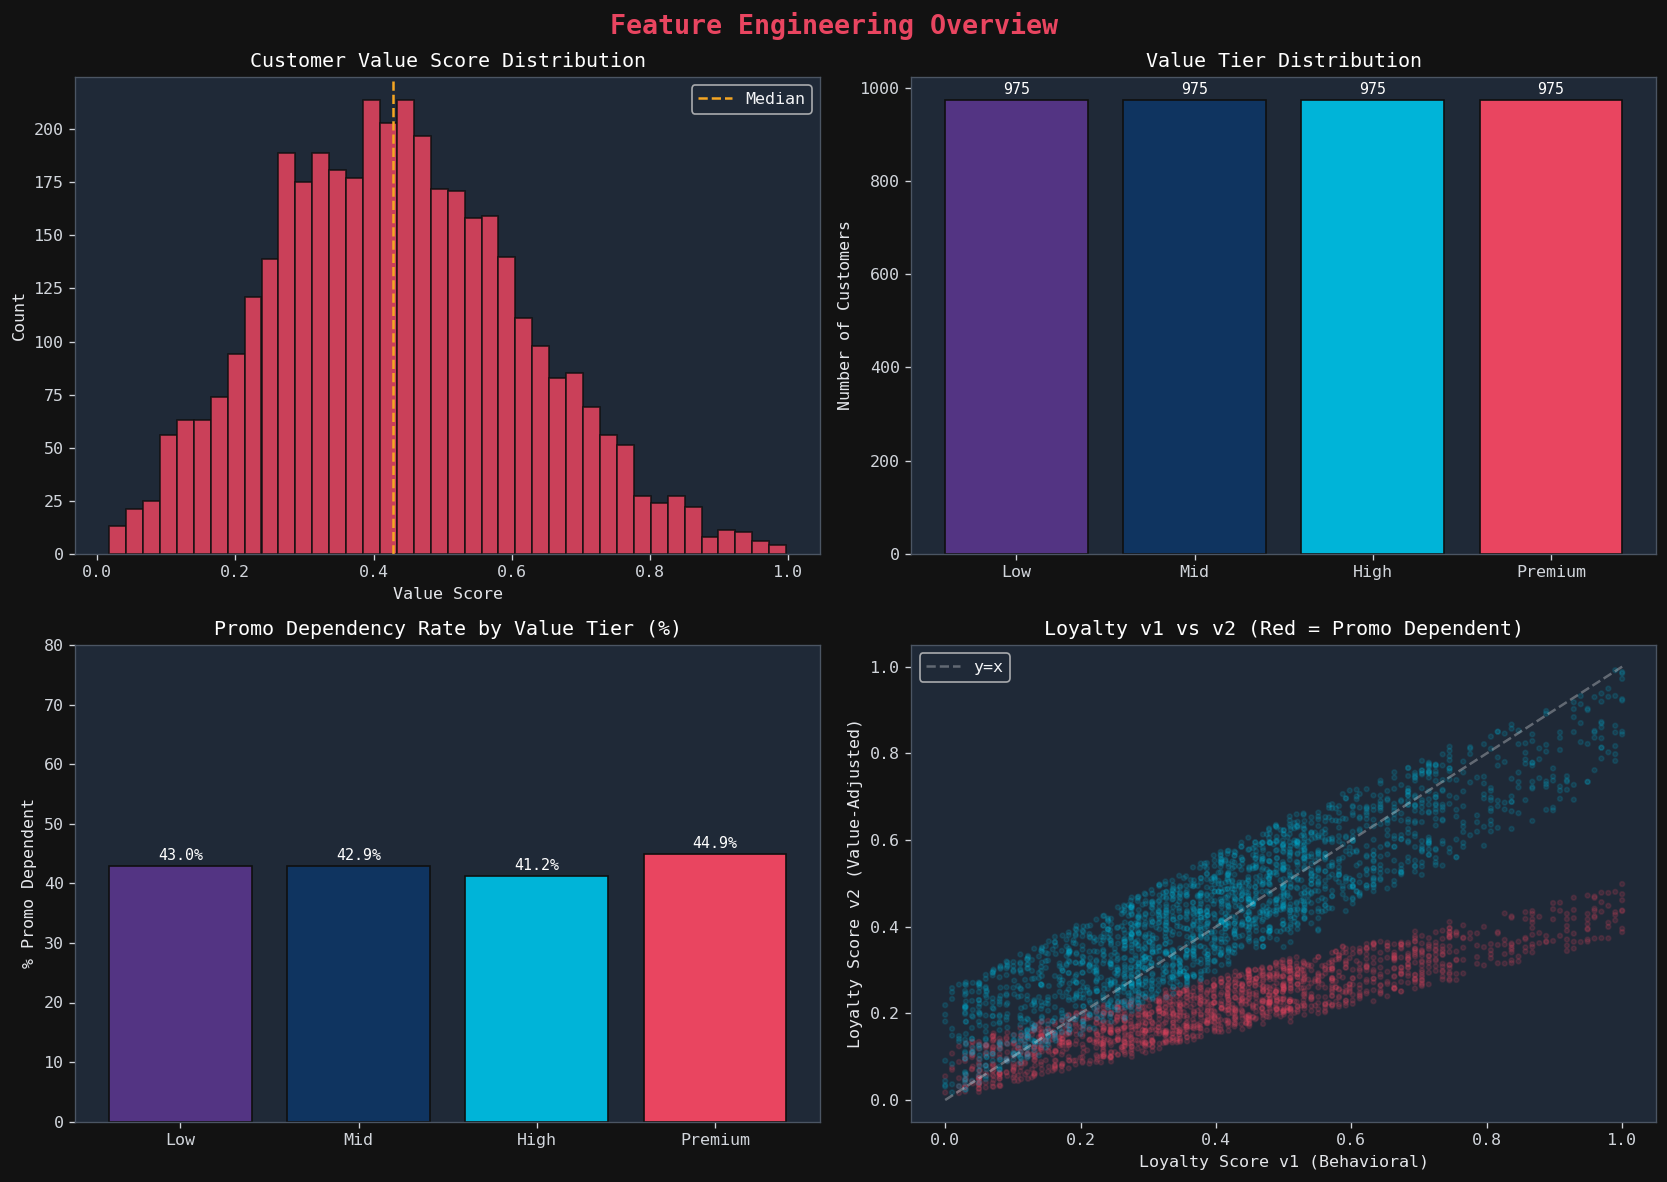

Chart saved.


In [14]:
# --- Plot 1: Customer Value Score Distribution ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Feature Engineering Overview', fontsize=16, fontweight='bold', color='#e94560')

# 1. Value Score distribution
ax = axes[0,0]
ax.hist(df_final['customer_value_score'], bins=40, color='#e94560', edgecolor='#0f0f0f', alpha=0.85)
ax.set_title('Customer Value Score Distribution')
ax.set_xlabel('Value Score')
ax.set_ylabel('Count')
ax.axvline(df_final['customer_value_score'].median(), color='#f5a623', linestyle='--', label='Median')
ax.legend()

# 2. Value Tier breakdown
ax = axes[0,1]
tier_counts = df_final['value_tier'].value_counts().reindex(['Low','Mid','High','Premium'])
bars = ax.bar(tier_counts.index, tier_counts.values, color=['#533483','#0f3460','#00b4d8','#e94560'], edgecolor='#0f0f0f')
ax.set_title('Value Tier Distribution')
ax.set_ylabel('Number of Customers')
for bar, val in zip(bars, tier_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, f'{val:,}', 
            ha='center', va='bottom', fontsize=9, color='white')

# 3. Promo Dependency by Value Tier
ax = axes[1,0]
promo_by_tier = df_final.groupby('value_tier')['promo_dependent'].mean().reindex(['Low','Mid','High','Premium'])
bars = ax.bar(promo_by_tier.index, promo_by_tier.values * 100, 
              color=['#533483','#0f3460','#00b4d8','#e94560'], edgecolor='#0f0f0f')
ax.set_title('Promo Dependency Rate by Value Tier (%)')
ax.set_ylabel('% Promo Dependent')
ax.set_ylim(0, 80)
for bar, val in zip(bars, promo_by_tier.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val*100:.1f}%', 
            ha='center', va='bottom', fontsize=9, color='white')

# 4. Loyalty v1 vs v2 scatter
ax = axes[1,1]
colors = ['#00b4d8' if p == 0 else '#e94560' for p in df_final['promo_dependent']]
ax.scatter(df_final['loyalty_score_v1'], df_final['loyalty_score_v2'], 
           c=colors, alpha=0.15, s=8)
ax.set_title('Loyalty v1 vs v2 (Red = Promo Dependent)')
ax.set_xlabel('Loyalty Score v1 (Behavioral)')
ax.set_ylabel('Loyalty Score v2 (Value-Adjusted)')
ax.plot([0,1],[0,1], color='white', alpha=0.3, linestyle='--', label='y=x')
ax.legend()

plt.tight_layout()
plt.savefig('../notebooks/feature_engineering_overview.png', bbox_inches='tight', dpi=150)
plt.show()
print('Chart saved.')

---
## 5. Export Dataset

In [15]:
df_final.to_csv(OUT_PATH, index=False)
print(f'Enriched dataset saved to: {OUT_PATH}')
print(f'Rows: {len(df_final):,} | Columns: {df_final.shape[1]}')
print()
print('Final columns exported:')
for col in df_final.columns:
    print(f'  {col}')

Enriched dataset saved to: ..\data\engineered\customer_features_enriched.csv
Rows: 3,900 | Columns: 27

Final columns exported:
  customer_id
  age
  gender
  item_purchased
  category
  purchase_amount_usd
  location
  size
  color
  season
  review_rating
  subscription_status
  shipping_type
  discount_applied
  promo_code_used
  previous_purchases
  payment_method
  frequency_of_purchases
  purchase_frequency_score
  promo_dependent
  high_satisfaction
  customer_value_score
  value_tier
  loyalty_score_v1
  loyalty_score_v2
  loyalty_score
  is_loyal


---
## 6. Engineered Features Summary

| Feature | Type | Logic | Business Question Answered |
|---------|------|--------|----------------------------|
| `purchase_frequency_score` | Numeric (1–52) | Frequency label → annual equivalent | How often does this customer shop? |
| `promo_dependent` | Binary (0/1) | Discount Applied = Yes | Is this customer only here for deals? |
| `high_satisfaction` | Binary (0/1) | Review Rating ≥ 4.0 | Does this customer genuinely like the brand? |
| `customer_value_score` | Numeric (0–1) | 40% prev_purchases + 35% freq + 25% spend | How valuable is this customer overall? |
| `value_tier` | Categorical | Quartile of value_score | Which strategic segment does this customer belong to? |
| `loyalty_score_v1` | Numeric (0–1) | 50% prev_purchases + 50% freq | Behavioral loyalty (frequency + tenure) |
| `loyalty_score_v2` | Numeric (0–1) | value_score × (1 − 0.5×promo_dependent) | Revenue-robust loyalty (penalised for promo use) |
| `loyalty_score` | Numeric (0–1) | = loyalty_score_v2 (argued winner) | Final loyalty signal used in SQL segmentation |
| `is_loyal` | Binary (0/1) | Top 50% loyalty AND not promo dependent | Binary loyal customer flag for dashboards |